# iMinuit fit for fitting of the corrected mass for $B_{0} \rightarrow D^{+}μν$

## Libraries

In [1]:
import ROOT
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm, truncexpon

from iminuit import Minuit
from iminuit.cost import ExtendedBinnedNLL, NormalConstraint
from iminuit.cost import Cost
from iminuit.cost import Template
import math

ROOT.TH1.SetDefaultSumw2(True)


Pythia8 loaded automatically


## Configuration

In [2]:
mCorr_min = 2000
mCorr_max = 8000
nBins = 50

mDp_sig_lo = 1840
mDp_sig_hi = 1900

scaling_SB = 2.8

## File loading

In [3]:
# MC
df_mc = ROOT.RDataFrame("DecayTree", "~/INFN/root_files/MC/MC_2_eff_with_mCorr.root")

h_Dp = df_mc.Filter("SL_category == 1").Histo1D(("h_Dp_w", "", nBins, mCorr_min, mCorr_max), "Bz_OWNPV_CORRM", "eff_Bz").GetPtr().Clone()
h_Dst = df_mc.Filter("SL_category == 2").Histo1D(("h_Dst_w", "", nBins, mCorr_min, mCorr_max), "Bz_OWNPV_CORRM", "eff_Bz").GetPtr().Clone()
h_Db = df_mc.Filter("SL_category == 31").Histo1D(("h_Dstst_broad_w", "", nBins, mCorr_min, mCorr_max), "Bz_OWNPV_CORRM", "eff_Bz").GetPtr().Clone()
h_Dn = df_mc.Filter("SL_category == 32").Histo1D(("h_Dstst_narrow_w", "", nBins, mCorr_min, mCorr_max), "Bz_OWNPV_CORRM", "eff_Bz").GetPtr().Clone()

for h in [h_Dp, h_Dst, h_Db, h_Dn]:
    h.SetDirectory(0)

# Data
df_data = ROOT.RDataFrame("DecayTree", "~/INFN/root_files/Data/Data_ALL_sw.root")
hData = df_data.Histo1D(("hData","",nBins,mCorr_min,mCorr_max),"cand_Bz_OWNPV_CORRM").GetPtr().Clone()
hData.SetDirectory(0)
hData_sw = df_data.Histo1D(("hData_sw","",nBins,mCorr_min,mCorr_max),"cand_Bz_OWNPV_CORRM", "N_sig_sw").GetPtr().Clone()
hData_sw.SetDirectory(0)

# Sideband
dfSB = df_data.Filter(f"cand_Bz_Dp_M<{mDp_sig_lo} || cand_Bz_Dp_M>{mDp_sig_hi}")
hSB = dfSB.Histo1D(("hSB","",nBins,mCorr_min,mCorr_max),"cand_Bz_OWNPV_CORRM").GetPtr().Clone()
hSB.SetDirectory(0)

# Wrong-sign for the signal region of the D+ mass
dfWS = ROOT.RDataFrame("DecayTree", "~/INFN/root_files/Data/Data_ALL_WS_sw.root")
hWS = dfWS.Filter(f"cand_Bz_Dp_M>{mDp_sig_lo} && cand_Bz_Dp_M<{mDp_sig_hi}") \
           .Histo1D(("hWS","",nBins,mCorr_min,mCorr_max),"cand_Bz_OWNPV_CORRM").GetPtr().Clone()
hWS.SetDirectory(0)
hWS_sw = dfWS.Histo1D(("hWS_sw","",nBins,mCorr_min,mCorr_max),"cand_Bz_OWNPV_CORRM", "N_sig_sw").GetPtr().Clone()
hWS_sw.SetDirectory(0)

## Fit assuming no MC uncertainties (ExtendedBinnedNLL)

### Sidebands

N_Dp   =  981909.78 ± 3525.87
N_Dst  =  798498.59 ± 4434.04
N_Db   =  205159.39 ± 2936.52
N_Dn   =  318979.84 ± 3309.84
N_SB   =  867474.30 ± 2485.46
N_WS   =       0.00 ± 6.20

Fit valid: True


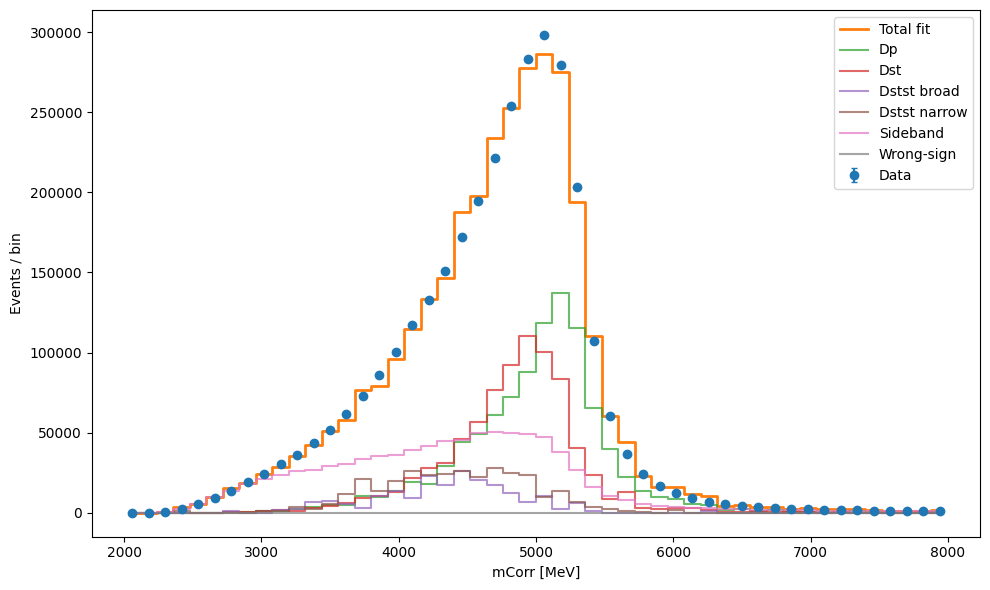

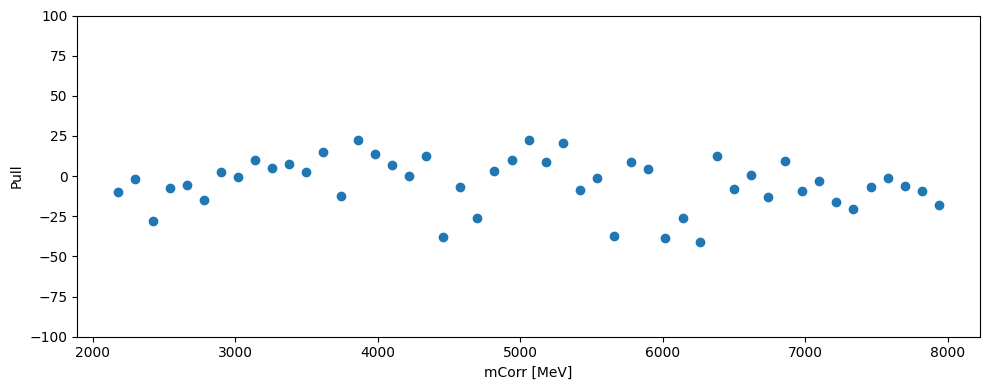

In [4]:
# Helpers
def th1_to_numpy(h):
    nb = h.GetNbinsX()
    edges = np.array([h.GetXaxis().GetBinLowEdge(i) for i in range(1, nb + 2)])
    contents = np.array([h.GetBinContent(i) for i in range(1, nb + 1)])
    return contents, edges

def make_pdf_from_hist(h):
    y, edges = th1_to_numpy(h)
    area = np.sum(y)
    pdf = y / area
    return pdf, edges

def pdf_to_cdf(pdf):
    return np.concatenate([[0.0], np.cumsum(pdf)])

# TH1 -> PDF -> CDF
pdf_Dp, edges_Dp = make_pdf_from_hist(h_Dp)
pdf_Dst, edges_Dst = make_pdf_from_hist(h_Dst)
pdf_Db, edges_Db = make_pdf_from_hist(h_Db)
pdf_Dn, edges_Dn = make_pdf_from_hist(h_Dn)

pdf_SB, edges_SB = make_pdf_from_hist(hSB)
pdf_WS, edges_WS = make_pdf_from_hist(hWS)

cdf_Dp  = pdf_to_cdf(pdf_Dp)
cdf_Dst = pdf_to_cdf(pdf_Dst)
cdf_Db  = pdf_to_cdf(pdf_Db)
cdf_Dn  = pdf_to_cdf(pdf_Dn)
cdf_SB  = pdf_to_cdf(pdf_SB)
cdf_WS  = pdf_to_cdf(pdf_WS)

n_data, edges_data = th1_to_numpy(hData)

# ExtendedBinnedNLL
def scaled_cdf_model(xe, N_Dp, N_Dst, N_Db, N_Dn, N_SB, N_WS):
    return (
        N_Dp  * cdf_Dp +
        N_Dst * cdf_Dst +
        N_Db  * cdf_Db +
        N_Dn  * cdf_Dn +
        N_SB  * cdf_SB +
        N_WS  * cdf_WS
    )

cost_nll = ExtendedBinnedNLL(n_data, edges_data, scaled_cdf_model)

m = Minuit(
    cost_nll,
    N_Dp=0.2 * np.sum(n_data),
    N_Dst=0.2 * np.sum(n_data),
    N_Db=0.1 * np.sum(n_data),
    N_Dn=0.1 * np.sum(n_data),
    N_SB=0.4 * np.sum(n_data),
    N_WS=0.1 * np.sum(n_data)
)

# yields must be >= 0 if turned off then WS negative
for name in ["N_Dp", "N_Dst", "N_Db", "N_Dn", "N_SB", "N_WS"]:
    m.limits[name] = (0, None)

m.migrad()
m.hesse()

for par in m.parameters:
    print(f"{par:6s} = {m.values[par]:10.2f} ± {m.errors[par]:.2f}")

print("\nFit valid:", m.valid)


# Plotting
bin_centers = 0.5 * (edges_data[:-1] + edges_data[1:])

N_Dp_fit  = m.values["N_Dp"]
N_Dst_fit = m.values["N_Dst"]
N_Db_fit  = m.values["N_Db"]
N_Dn_fit  = m.values["N_Dn"]
N_SB_fit  = m.values["N_SB"]
N_WS_fit  = m.values["N_WS"]

model_counts = (
    N_Dp_fit  * pdf_Dp +
    N_Dst_fit * pdf_Dst +
    N_Db_fit  * pdf_Db +
    N_Dn_fit  * pdf_Dn +
    N_SB_fit  * pdf_SB +
    N_WS_fit  * pdf_WS
)

plt.figure(figsize=(10, 6))
plt.errorbar(bin_centers, n_data, yerr=np.sqrt(n_data), fmt="o", label="Data", capsize=2)
plt.step(bin_centers, model_counts, where="mid", label="Total fit", linewidth=2)

plt.step(bin_centers, N_Dp_fit  * pdf_Dp,  where="mid", label="Dp", alpha=0.7)
plt.step(bin_centers, N_Dst_fit * pdf_Dst, where="mid", label="Dst", alpha=0.7)
plt.step(bin_centers, N_Db_fit  * pdf_Db,  where="mid", label="Dstst broad", alpha=0.7)
plt.step(bin_centers, N_Dn_fit  * pdf_Dn,  where="mid", label="Dstst narrow", alpha=0.7)
plt.step(bin_centers, N_SB_fit  * pdf_SB,  where="mid", label="Sideband", alpha=0.7)
plt.step(bin_centers, N_WS_fit  * pdf_WS,  where="mid", label="Wrong-sign", alpha=0.7)

plt.xlabel("mCorr [MeV]")
plt.ylabel("Events / bin")
plt.legend()
plt.tight_layout()
plt.show()

# Pulls
pull = cost_nll.pulls(m.values)

plt.figure(figsize=(10, 4))

plt.plot(bin_centers, pull, "o")

plt.xlabel("mCorr [MeV]")
plt.ylabel("Pull")
plt.ylim(-100, 100)
plt.tight_layout()
plt.show()




### sWeights

N_Dp   = 1039252.66 ± 3358.98
N_Dst  =  888218.08 ± 4253.44
N_Db   =  376037.86 ± 3000.62
N_Dn   =  499745.23 ± 3148.42
N_WS_sw =  234455.18 ± 936.68

Fit valid: True


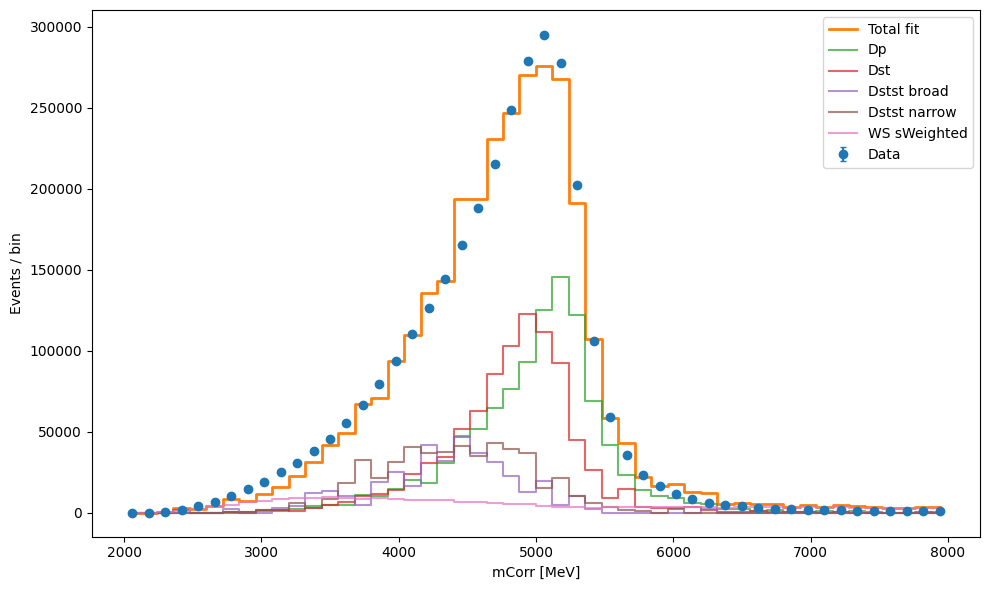

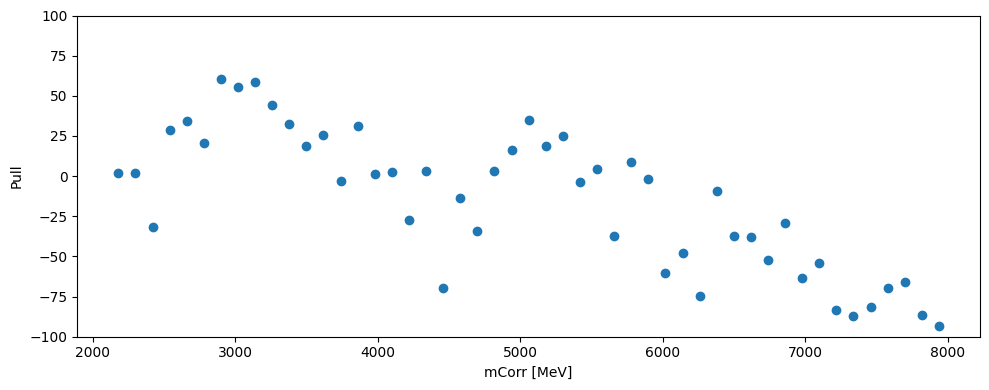

In [5]:
pdf_WS_sw, edges_WS_sw = make_pdf_from_hist(hWS_sw)

cdf_WS_sw  = pdf_to_cdf(pdf_WS_sw)

n_data_sw, edges_data_sw = th1_to_numpy(hData_sw)

# ExtendedBinnedNLL
def scaled_cdf_model_sw(xe, N_Dp, N_Dst, N_Db, N_Dn, N_WS_sw):
    return (
        N_Dp  * cdf_Dp +
        N_Dst * cdf_Dst +
        N_Db  * cdf_Db +
        N_Dn  * cdf_Dn +
        N_WS_sw  * cdf_WS_sw
    )

cost_nll_sw = ExtendedBinnedNLL(n_data_sw, edges_data_sw, scaled_cdf_model_sw)

m = Minuit(
    cost_nll_sw,
    N_Dp=0.2 * np.sum(n_data_sw),
    N_Dst=0.2 * np.sum(n_data_sw),
    N_Db=0.1 * np.sum(n_data_sw),
    N_Dn=0.1 * np.sum(n_data_sw),
    N_WS_sw=0.1 * np.sum(n_data_sw)
)

# yields must be >= 0 if turned off then WS negative
for name in ["N_Dp", "N_Dst", "N_Db", "N_Dn", "N_WS_sw"]:
    m.limits[name] = (0, None)

m.migrad()
m.hesse()

for par in m.parameters:
    print(f"{par:6s} = {m.values[par]:10.2f} ± {m.errors[par]:.2f}")

print("\nFit valid:", m.valid)


# Plotting
bin_centers_sw = 0.5 * (edges_data_sw[:-1] + edges_data_sw[1:])

N_Dp_fit  = m.values["N_Dp"]
N_Dst_fit = m.values["N_Dst"]
N_Db_fit  = m.values["N_Db"]
N_Dn_fit  = m.values["N_Dn"]
N_WS_sw_fit  = m.values["N_WS_sw"]

model_sw_counts = (
    N_Dp_fit  * pdf_Dp +
    N_Dst_fit * pdf_Dst +
    N_Db_fit  * pdf_Db +
    N_Dn_fit  * pdf_Dn +
    N_WS_sw_fit  * pdf_WS_sw
)

plt.figure(figsize=(10, 6))
plt.errorbar(bin_centers_sw, n_data_sw, yerr=np.sqrt(n_data_sw), fmt="o", label="Data", capsize=2)
plt.step(bin_centers_sw, model_sw_counts, where="mid", label="Total fit", linewidth=2)

plt.step(bin_centers_sw, N_Dp_fit  * pdf_Dp,  where="mid", label="Dp", alpha=0.7)
plt.step(bin_centers_sw, N_Dst_fit * pdf_Dst, where="mid", label="Dst", alpha=0.7)
plt.step(bin_centers_sw, N_Db_fit  * pdf_Db,  where="mid", label="Dstst broad", alpha=0.7)
plt.step(bin_centers_sw, N_Dn_fit  * pdf_Dn,  where="mid", label="Dstst narrow", alpha=0.7)
plt.step(bin_centers_sw, N_WS_sw_fit  * pdf_WS_sw,  where="mid", label="WS sWeighted", alpha=0.7)

plt.xlabel("mCorr [MeV]")
plt.ylabel("Events / bin")
plt.legend()
plt.tight_layout()
plt.show()

# Pulls
pull_sw = cost_nll_sw.pulls(m.values)

plt.figure(figsize=(10, 4))

plt.plot(bin_centers_sw, pull_sw, "o")

plt.xlabel("mCorr [MeV]")
plt.ylabel("Pull")
plt.ylim(-100, 100)
plt.tight_layout()
plt.show()


## Fit with DA method (not working properly)

### Helpers

In [6]:
def th1_to_array(h):
    nb = h.GetNbinsX()

    sumw  = np.zeros(nb, float)
    sumw2 = np.zeros(nb, float)

    for i in range(1, nb+1):
        sw  = h.GetBinContent(i)
        sw2 = h.GetSumw2()[i]
        
        sumw[i-1]  = sw
        sumw2[i-1] = sw2

    return np.stack([sumw, sumw2], axis=-1)


def th1_edges(h):
    ax = h.GetXaxis()

    edges = np.empty(nBins + 1)

    for i in range(1, nBins+1):
        edges[i-1] = ax.GetBinLowEdge(i)

    edges[nBins] = ax.GetBinUpEdge(nBins)

    return edges

# MC templates
t_Dp  = th1_to_array(h_Dp)
t_Dst = th1_to_array(h_Dst)
t_Db  = th1_to_array(h_Db)
t_Dn  = th1_to_array(h_Dn)

### Sidebands scaled method

In [7]:
# data
n = th1_to_array(hData)
xe = th1_edges(hData)

# background template from sideband
t_SB  = th1_to_array(hSB)
t_WS  = th1_to_array(hWS)

cost = Template(
    n,
    xe,
    model_or_template = [t_Dp, t_Dst, 
                         t_Db, t_Dn, 
                         t_SB, t_WS],
    name=["N_Dp", "N_Dst", 
          "N_Db", "N_Dn", 
          "N_SB", "N_WS"]
)

m = Minuit(cost,
           N_Dp=1.0184e6,
           N_Dst=8.9605e5,
           N_Db=1.6715e5,
           N_Dn=6.7134e5,
           N_SB=1.2913e5, N_WS=2.8263e5)

#m.fixed["N_SB"] = True
#m = Minuit(cost,
#           N_Dp=1.0184e6,
#           N_Dst=8.9605e5,
#           N_Db=1.6715e5,
#           N_Dn=6.7134e5,
#           N_SB=1.2913e5, N_WS=2.8263e5)


m.migrad()
m.minos()

#for name in m.parameters:
#    err = m.merrors[name]
#    print(f"{name}:")
#    print(f"   value = {m.values[name]}")
#    print(f"   lower = {err.lower} which is {100*err.lower/m.values[name]}%")
#    print(f"   upper = {err.upper} which is {100*err.upper/m.values[name]}%")



┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 52.99 (χ²/ndof = 1.2)      │             Nfcn = 1674              │
│ EDM = 9.62e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N_Dp  │  0.99e6   │  0.06e6   │  -0.06e6   │   0.06e6   │    0    │         │       │
│ 1 │ N_Dst │  0.78e6   │  0.08e6   │  -0.09e6   │   0.08e6   │    0    │         │       │
│ 2 │ N_Db  │  0.30e6   │  0.08e6   │  -0.09e6   │   0.09e6   │    0    │         │       │
│ 3 │ N_Dn  │  0.29e6   │  0.09e6   │  -0.09e6   │   0.10e6   │    0    │         │       │
│ 4 │ N_SB  │  0.829e6  │  0.016e6  │  -0.017e6  │  0.017e6   │    0    │         │       │
│ 5 │ N_WS  │   0.034   │  89.725   │   -0.034   │   89.725   │    0    │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │         N_Dp          │         N_Dst         │         N_Db          │         N_Dn          │         N_SB          │         N_WS          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.06e6  │  0.06e6   │  -0.09e6  │  0.08e6   │  -0.08e6  │  0.09e6   │  -0.09e6  │  0.10e6   │ -0.017e6  │  0.017e6  │  -0.034   │  89.725   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   False   │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───────┬───────────────────────────────────────────────────────┐
│       │     N_Dp    N_Dst     N_Db     N_Dn     N_SB     N_WS │
├───────┼───────────────────────────────────────────────────────┤
│  N_Dp │ 3.71e+09     -4e9      0e9      1e9  -0.12e9  -21.7e3 │
│ N_Dst │     -4e9 7.14e+09      0e9     -3e9  -0.01e9  -30.4e3 │
│  N_Db │      0e9      0e9 6.72e+09     -6e9   0.01e9   23.5e3 │
│  N_Dn │      1e9     -3e9     -6e9 8.12e+09  -0.14e9   32.4e3 │
│  N_SB │  -0.12e9  -0.01e9   0.01e9  -0.14e9 2.65e+08   -9.5e3 │
│  N_WS │  -21.7e3  -30.4e3   23.5e3   32.4e3   -9.5e3      527 │
└───────┴───────────────────────────────────────────────────────┘

#### Plotting in components

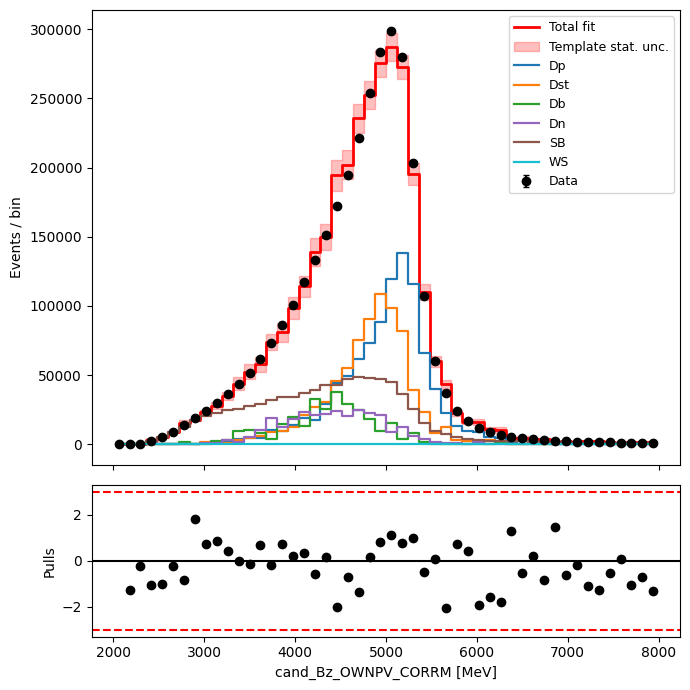

In [8]:
y, yerr = cost.prediction(m.values)

t_Dp = th1_to_array(h_Dp)[:,0]
t_Dst = th1_to_array(h_Dst)[:,0]
t_Db = th1_to_array(h_Db)[:,0]
t_Dn = th1_to_array(h_Dn)[:,0]
t_SB = th1_to_array(hSB)[:,0]
t_WS = th1_to_array(hWS)[:,0]

templates = {
    "Dp":  t_Dp,
    "Dst": t_Dst,
    "Db":  t_Db,
    "Dn":  t_Dn,
    "SB":  t_SB,
    "WS":  t_WS
}

components = {}

for k in templates:
    templates[k] = templates[k] / np.sum(templates[k])

for name, temp in templates.items():
    yield_value = m.values["N_" + name]
    components[name] = yield_value * temp

# binning
edges   = xe
centers = 0.5 * (edges[1:] + edges[:-1])

data     = n[:,0]
data_err = np.sqrt(n[:,1])

fig, (ax, rax) = plt.subplots(
    2, 1,
    figsize=(7,7),
    gridspec_kw={"height_ratios":[3,1]},
    sharex=True
)

# data
ax.errorbar(
    centers, data, yerr=data_err,
    fmt='o', color='black', capsize=2, label='Data'
)

# total fit
ax.step(centers, y, where='mid', color='red', lw=2, label='Total fit')

# uncertainty band
ax.fill_between(
    centers,
    y - yerr,
    y + yerr,
    step='mid',
    color='red',
    alpha=0.25,
    label='Template stat. unc.'
)

# individual templates
colors = ['tab:blue','tab:orange','tab:green','tab:purple','tab:brown','tab:cyan']

for (name, comp), c in zip(components.items(), colors):
    ax.step(
        centers,
        comp,
        where='mid',
        lw=1.6,
        color=c,
        label=name.replace("N_","")
    )

ax.set_ylabel("Events / bin")
handles, labels = ax.get_legend_handles_labels()

unique = dict(zip(labels, handles))

ax.legend(unique.values(), unique.keys(), fontsize=9)


# pulls
pulls = cost.pulls(m.values)

rax.axhline(0, color='black')
rax.axhline(3, color='red', ls='--')
rax.axhline(-3, color='red', ls='--')

rax.plot(centers, pulls, 'o', color='black')
rax.set_ylabel("Pulls")
rax.set_xlabel("cand_Bz_OWNPV_CORRM [MeV]")

plt.tight_layout()

plt.savefig(
    "mCorr_template_fit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#### MC Statistical Uncertainty & Scaling

The following script quantifies the impact of finite MC statistics on our template shapes and estimates the required scale factor to reach a target precision (e.g., 5% or 1%). 

It processes the bin contents (sumw) and variances (sumw2) for all templates, applying a mask (y > 2200) to evaluate only the statistically relevant bins.

#### 1. Template Prediction & Variance
For a given MC component $k$ in bin $i$, the predicted yield is:
$$m_{ik} = \theta_k T_{ik}$$
where $\theta_k$ (`thetas`) is the total normalization parameter from the fit, and $T_{ik}$ (`T`) is the normalized template shape. 

The variance of this normalized shape, denoted as $\sigma_{ik}^2$ (`var_T`), is calculated from the sum of squared weights divided by the squared sum of all weights. The standard deviation of the predicted bin content is then the total yield times this shape uncertainty:
$$\text{StdDev}(m_{ik}) = \theta_k \sigma_{ik}$$
*(In the code, this is `sigma_comp_m = thetas * sqrt(var_T)`)*

#### 2. Relative Statistical Uncertainty (How much a template's uncertainty affects the total fit yield -> if a MC component is small, its relative impact is small)
To understand how a single template's limited statistics affect the overall fit, we calculate its uncertainty relative to the total predicted bin content $y_i$ (`y_m`):
$$\delta_{ik} = \frac{\text{StdDev}(m_{ik})}{y_i} = \frac{\theta_k \sigma_{ik}}{y_i}$$
*(In the code, this is `rel_comp_m = sigma_comp_m / y_m`)*

#### 3. Intrinsic Template Uncertainty (How much a template fluctuates on its own, regardless of the rest of the fit)
The script also calculates the intrinsic fluctuation of the template relative to its own size in that bin, independent of the overall fit fractions. This is simply the template standard deviation divided by the template value:
$$\text{Intrinsic Error}_{ik} = \frac{\sigma_{ik}}{T_{ik}}$$
*(In the code, this is `rel_intr_m = sqrt(var_T) / T`)*

#### 4. Required MC Scale Factor
Because the weight distribution remains unchanged when increasing MC statistics, both the relative and intrinsic uncertainties scale inversely with the square root of the number of MC events ($N_{\text{MC}}$):
$$\delta_{ik} \propto \frac{1}{\sqrt{N_{\text{MC}}}}$$

Consequently, to move from our current uncertainty ($\delta_{\text{current}}$) to a specific target precision ($\delta_{\text{target}}$), the required scale factor for generating more MC is:
$$\text{scale factor} = \left( \frac{\delta_{\text{current}}}{\delta_{\text{target}}} \right)^2$$
*(In the code, this scaling is calculated for both the maximum bin error and the mean error across valid bins to estimate how much more MC to request)*

In [13]:
thetas = np.array(m.values)[:4] # not for SB, WS
names = ["Dp", "Dst", "Db", "Dn"]

templates = np.array([
    th1_to_array(h_Dp), 
    th1_to_array(h_Dst), 
    th1_to_array(h_Db), 
    th1_to_array(h_Dn)
])

sumw, sumw2 = templates[..., 0], templates[..., 1]

norm = np.sum(sumw, axis=1, keepdims=True)
T = sumw / norm
var_T = sumw2 / norm**2

# Mask
mask = y > 2200
valid_bins = np.where(mask)[0]
y_m = y[mask]

# Calculate uncertainties for masked bins
sigma_comp_m = (thetas[:, None] * np.sqrt(var_T))[:, mask]
rel_comp_m = sigma_comp_m / y_m  # Relative to total fit yield

rel_intr_m = np.divide(
    np.sqrt(var_T[:, mask]), 
    T[:, mask], 
    out=np.zeros_like(T[:, mask]), 
    where=(T[:, mask] > 0) # avoid division with 0
)

def print_mc_scaling(title, rel_matrix, targets):
    print(f"\n{title}")
    for i, name in enumerate(names):
        r_arr = rel_matrix[i]
        c_max, c_mean = np.max(r_arr), np.mean(r_arr)
        max_bin = valid_bins[np.argmax(r_arr)]
        
        print(f"{name:5s} max: {100*c_max:5.2f}% (bin {max_bin:<2}) | mean: {100*c_mean:5.2f}%")
        for t in targets:
            print(f"    Target {t*100:g}% -> Need ~{(c_max/t)**2:5.1f}x (max), ~{(c_mean/t)**2:5.1f}x (mean) more MC")

print_mc_scaling("=== RELATIVE UNCERTAINTY ===", rel_comp_m, targets=[0.05, 0.01])
print_mc_scaling("=== INTRINSIC UNCERTAINTY ===", rel_intr_m, targets=[0.05])


=== RELATIVE UNCERTAINTY ===
Dp    max: 25.50% (bin 44) | mean:  5.61%
    Target 5% -> Need ~ 26.0x (max), ~  1.3x (mean) more MC
    Target 1% -> Need ~650.4x (max), ~ 31.5x (mean) more MC
Dst   max: 18.14% (bin 41) | mean:  3.81%
    Target 5% -> Need ~ 13.2x (max), ~  0.6x (mean) more MC
    Target 1% -> Need ~328.9x (max), ~ 14.6x (mean) more MC
Db    max: 15.83% (bin 35) | mean:  3.09%
    Target 5% -> Need ~ 10.0x (max), ~  0.4x (mean) more MC
    Target 1% -> Need ~250.6x (max), ~  9.5x (mean) more MC
Dn    max: 30.40% (bin 3 ) | mean:  2.70%
    Target 5% -> Need ~ 37.0x (max), ~  0.3x (mean) more MC
    Target 1% -> Need ~924.0x (max), ~  7.3x (mean) more MC

=== INTRINSIC UNCERTAINTY ===
Dp    max: 100.00% (bin 6 ) | mean: 25.09%
    Target 5% -> Need ~400.0x (max), ~ 25.2x (mean) more MC
Dst   max: 100.00% (bin 6 ) | mean: 30.76%
    Target 5% -> Need ~400.0x (max), ~ 37.9x (mean) more MC
Db    max: 100.00% (bin 6 ) | mean: 28.63%
    Target 5% -> Need ~400.0x (max), ~ 32.

### sWeights method

In [10]:
# data
n_sw = th1_to_array(hData_sw)
xe_sw = th1_edges(hData_sw)
t_WS_sw  = th1_to_array(hWS_sw)

templates = [t_Dp, t_Dst, t_Db, t_Dn, t_WS_sw]

cost_sw = Template(
    n_sw,
    xe_sw,
    model_or_template=[t_Dp, t_Dst, t_Db, t_Dn, t_WS_sw],
    name=["N_Dp", "N_Dst", "N_Db", "N_Dn", "N_WS"]
)

m_sw = Minuit(cost_sw,
           N_Dp=1.0184e6,
           N_Dst=8.9605e5,
           N_Db=1.6715e5,
           N_Dn=6.7134e5, N_WS=2.8263e5)

m_sw.migrad()
m_sw.hesse()
m_sw.minos()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 930.3 (χ²/ndof = 20.7)     │             Nfcn = 2056              │
│ EDM = 2.03e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N_Dp  │  1.25e6   │  0.20e6   │  -0.09e6   │   0.09e6   │    0    │         │       │
│ 1 │ N_Dst │  0.93e6   │  0.26e6   │  -0.11e6   │   0.11e6   │    0    │         │       │
│ 2 │ N_Db  │  0.43e6   │  0.25e6   │  -0.08e6   │   0.09e6   │    0    │         │       │
│ 3 │ N_Dn  │  0.41e6   │  0.06e6   │  -0.09e6   │   0.10e6   │    0    │         │       │
│ 4 │ N_WS  │   191e3   │   16e3    │    -5e3    │    5e3     │    0    │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │         N_Dp          │         N_Dst         │         N_Db          │         N_Dn          │         N_WS          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.09e6  │  0.09e6   │  -0.11e6  │  0.11e6   │  -0.08e6  │  0.09e6   │  -0.09e6  │  0.10e6   │   -5e3    │    5e3    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───────┬──────────────────────────────────────────────┐
│       │     N_Dp    N_Dst     N_Db     N_Dn     N_WS │
├───────┼──────────────────────────────────────────────┤
│  N_Dp │ 4.14e+10  0.05e12  0.05e12     12e9   3.26e9 │
│ N_Dst │  0.05e12 6.82e+10  0.07e12     16e9   4.17e9 │
│  N_Db │  0.05e12  0.07e12 6.41e+10     16e9   4.06e9 │
│  N_Dn │     12e9     16e9     16e9 3.89e+09   0.99e9 │
│  N_WS │   3.26e9   4.17e9   4.06e9   0.99e9 2.66e+08 │
└───────┴──────────────────────────────────────────────┘

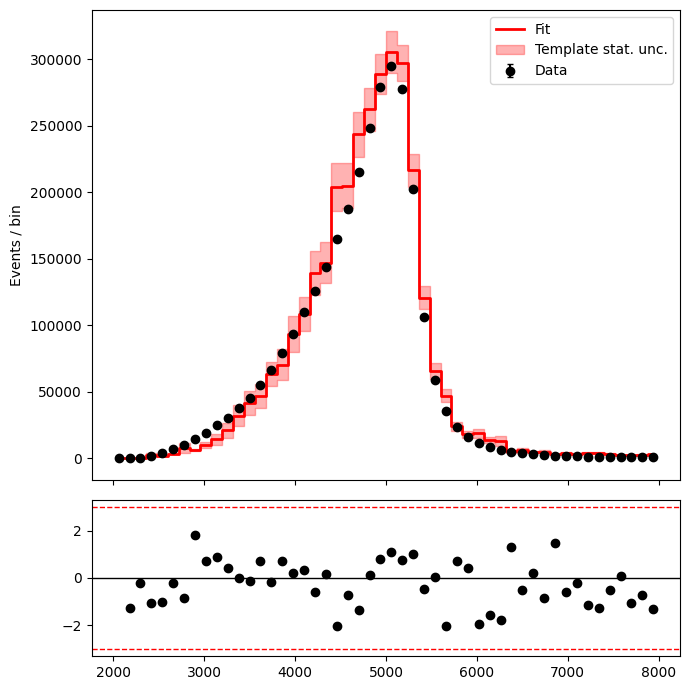

In [15]:
y, yerr = cost_sw.prediction(m_sw.values)

edges = xe_sw
centers = 0.5 * (edges[1:] + edges[:-1])
widths = edges[1:] - edges[:-1]

data = n_sw[:,0]
data_err = np.sqrt(n_sw[:,1])

fig, (ax, rax) = plt.subplots(
    2, 1,
    figsize=(7,7),
    gridspec_kw={"height_ratios":[3,1]},
    sharex=True
)

ax.errorbar(
    centers, data, yerr=data_err,
    fmt='o', color='black', label='Data', capsize=2
)

ax.step(centers, y, where='mid', color='red', lw=2, label='Fit')

ax.fill_between(
    centers,
    y - yerr,
    y + yerr,
    step='mid',
    color='red',
    alpha=0.3,
    label='Template stat. unc.'
)

ax.set_ylabel("Events / bin")
ax.legend()
ax.set_yscale("linear")

pulls = cost.pulls(m.values)

rax.axhline(0, color='black', lw=1)
rax.axhline(3, color='red', ls='--', lw=1)
rax.axhline(-3, color='red', ls='--', lw=1)

rax.plot(centers, pulls, 'o', color='black')

plt.tight_layout()
plt.show()
